In [1]:
pip install earthengine-api geemap --break-system-packages

In [2]:
import ee
import geemap
ee.Authenticate()
# Initialize with your project
ee.Initialize(project='osmgee')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [3]:
# ============================================
# Load feature collections, including HUC8 boundaries
# ============================================

wetlands = ee.FeatureCollection('projects/osmgee/assets/OSM_Wetland')
watersheds = ee.FeatureCollection('projects/osmgee/assets/OSM_Watersheds')
huc8s = ee.FeatureCollection('projects/osmgee/assets/OSR_HUC8')

print('Wetland feature count:', wetlands.size().getInfo())
print('Watershed feature count:', watersheds.size().getInfo())
print('HUC8 feature count:', huc8s.size().getInfo())

# ============================================
# Geometries used downstream
# ============================================

wetland_geom = wetlands.geometry()
watershed_geom = watersheds.geometry()
huc8_geom = huc8s.geometry()

# ============================================
# Clip watersheds to HUC8 boundaries (intersection)
# ============================================

clippedWatershed_geom = watershed_geom.intersection(huc8_geom, maxError=1)

# Materialize once so the expensive vector op isn't recomputed downstream
clippedWatershed_geom = ee.Geometry(clippedWatershed_geom.getInfo())

print('Clipped watershed geometry materialized.')

Wetland feature count: 121
Watershed feature count: 121
HUC8 feature count: 110
Clipped watershed geometry materialized.


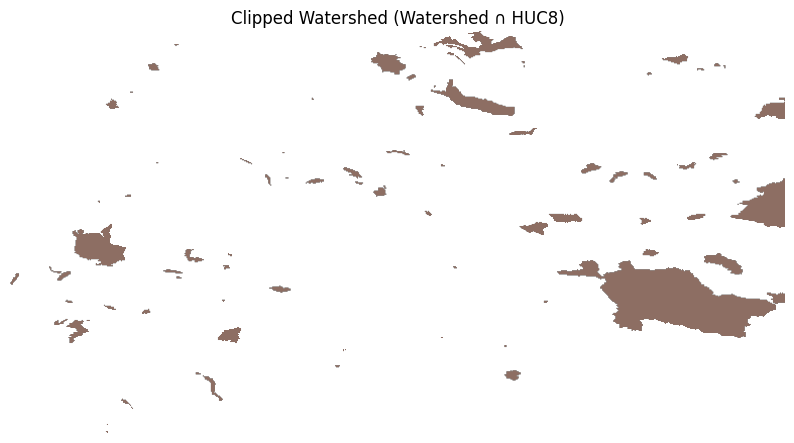

In [4]:
# ============================================
# Visualize clippedWatershed_geom only
# ============================================

clipped_feature = ee.FeatureCollection([ee.Feature(clippedWatershed_geom)])

clipped_image = ee.Image().byte().paint(
    featureCollection=clipped_feature,
    color=1
)

thumb_url = clipped_image.getThumbURL({
    'min': 0,
    'max': 1,
    'palette': ['white', '#8D6E63'],
    'dimensions': 768,
    'region': clippedWatershed_geom,
})

import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.title('Clipped Watershed (Watershed \u2229 HUC8)')
plt.show()

In [7]:
# ============================================
# Study period and growing season window
# ============================================
start_year = 1985
end_year = 2025

start_month = 6   # June
end_month = 8     # August

In [8]:
fitted_saved_excl = ee.Image('projects/annual-ccdc-new/assets/LandTrendr_NDVI_fitted_excl1987_2000_watershed')

print('Bands:', fitted_saved_excl.bandNames().getInfo())   # should be 39 bands

# Zonal mean per year, watershed — 1987 and 2000 are not in this asset
years_check_excl = [y for y in range(start_year, end_year + 1) if y not in [1987, 2000]]
mean_ndvi_fitted_excl = []

for y in years_check_excl:
    band_name = f'NDVI_fitted_{y}'
    mean_val = fitted_saved_excl.select(band_name).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=clippedWatershed_geom,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    ).get(band_name).getInfo()
    mean_ndvi_fitted_excl.append(mean_val)
    print(f'{y}: {mean_val}')

Bands: ['NDVI_fitted_1985', 'NDVI_fitted_1986', 'NDVI_fitted_1988', 'NDVI_fitted_1989', 'NDVI_fitted_1990', 'NDVI_fitted_1991', 'NDVI_fitted_1992', 'NDVI_fitted_1993', 'NDVI_fitted_1994', 'NDVI_fitted_1995', 'NDVI_fitted_1996', 'NDVI_fitted_1997', 'NDVI_fitted_1998', 'NDVI_fitted_1999', 'NDVI_fitted_2001', 'NDVI_fitted_2002', 'NDVI_fitted_2003', 'NDVI_fitted_2004', 'NDVI_fitted_2005', 'NDVI_fitted_2006', 'NDVI_fitted_2007', 'NDVI_fitted_2008', 'NDVI_fitted_2009', 'NDVI_fitted_2010', 'NDVI_fitted_2011', 'NDVI_fitted_2012', 'NDVI_fitted_2013', 'NDVI_fitted_2014', 'NDVI_fitted_2015', 'NDVI_fitted_2016', 'NDVI_fitted_2017', 'NDVI_fitted_2018', 'NDVI_fitted_2019', 'NDVI_fitted_2020', 'NDVI_fitted_2021', 'NDVI_fitted_2022', 'NDVI_fitted_2023', 'NDVI_fitted_2024', 'NDVI_fitted_2025']
1985: 0.6134411170307885
1986: 0.6160893324848858
1988: 0.6112514499761134
1989: 0.6093051615287319
1990: 0.6065736388090233
1991: 0.6035720661895135
1992: 0.6005297478315044
1993: 0.5967400172692803
1994: 0.5950

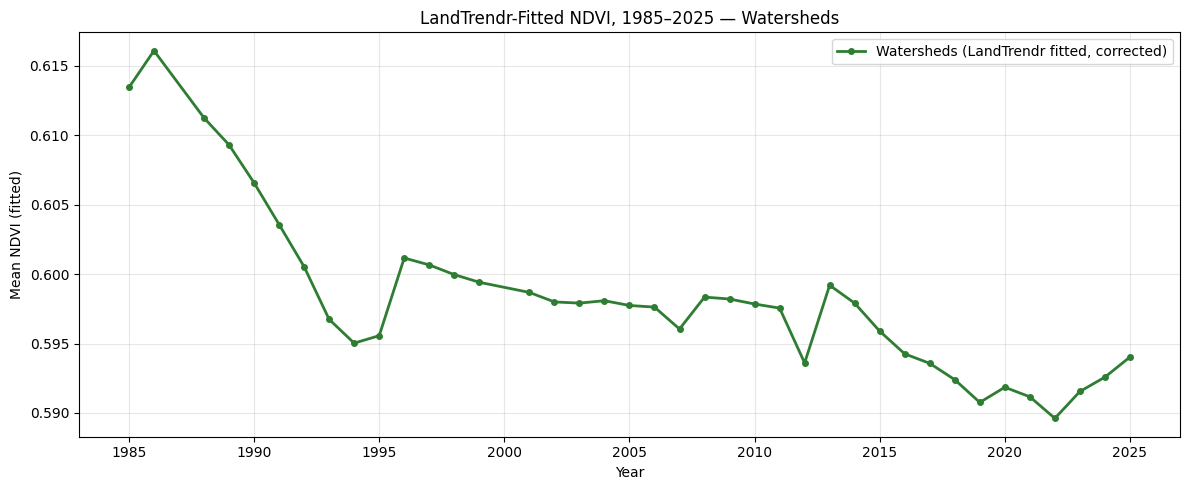

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(years_check_excl, mean_ndvi_fitted_excl, marker='o', markersize=4,
         linewidth=2, color='#2E7D32', label='Watersheds (LandTrendr fitted, corrected)')
plt.xlabel('Year')
plt.ylabel('Mean NDVI (fitted)')
plt.title('LandTrendr-Fitted NDVI, 1985–2025 — Watersheds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ndvi_timeseries_watershed_fitted_v2.png', dpi=150)
plt.show()

In [13]:
# ============================================
# Regenerate raw watershed NDVI means (if not already in this session)
# ============================================

def get_mean_ndvi_watershed(image):
    mean_dict = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=watershed_geom,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    return image.set('mean_ndvi', mean_dict.get('NDVI'))


annual_watershed_mean = annual_ndvi_collection.map(get_mean_ndvi_watershed)

years_watershed_list = annual_watershed_mean.aggregate_array('year').getInfo()
mean_ndvi_watershed = annual_watershed_mean.aggregate_array('mean_ndvi').getInfo()

print('Years:', years_watershed_list)
print('Raw watershed mean NDVI:', mean_ndvi_watershed)

Years: [1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Raw watershed mean NDVI: [0.5777615811742335, 0.5881050160029013, 0.5873906866731476, 0.6098949239034432, 0.6332077621504696, 0.6265142193042724, 0.6123972806663496, 0.5753845740918005, 0.5718859215218012, 0.5676733919132827, 0.5636359218488006, 0.6140437626573346, 0.6201222596082456, 0.5588523580345842, 0.586302821799413, 0.6079080532999791, 0.6306001205504916, 0.5639837652923062, 0.6176798201416208, 0.5847317657415565, 0.5816952465279575, 0.6029208724336558, 0.5749702950591907, 0.6075458943546719, 0.6123024468622081, 0.5978299380726358, 0.5744911823710817, 0.6188368648533773, 0.6301879411875937, 0.6398551291737447, 0.5770591858021196, 0.5464327881860843, 0.5892666161816931, 0.5821678778791621, 0.5947216497716356, 0.6281475112916846, 0

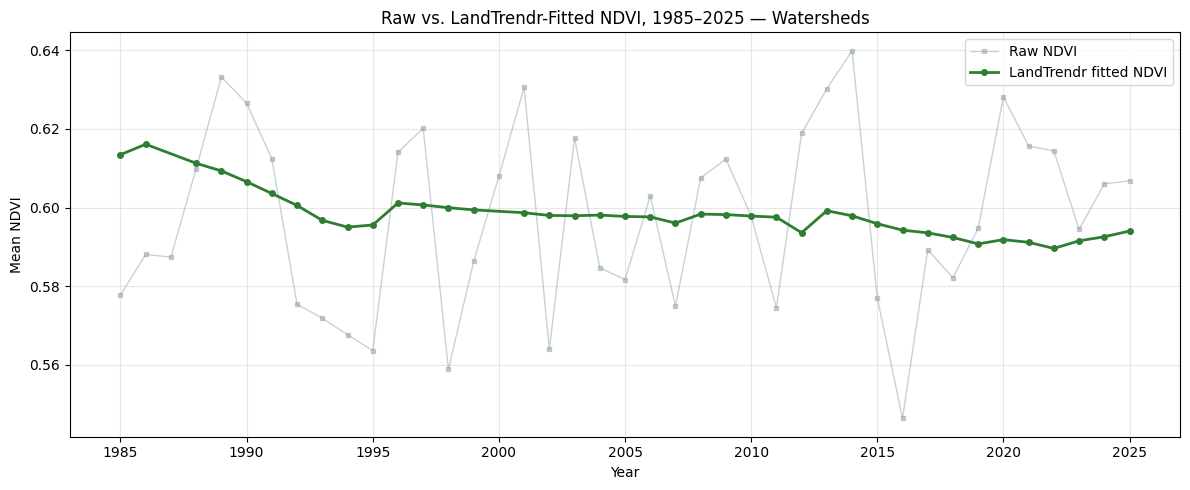

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Raw — thinner, lighter, semi-transparent, drawn first (behind)
plt.plot(years_watershed_list, mean_ndvi_watershed, marker='s', markersize=3,
         linewidth=1, color='#90A4AE', alpha=0.5, label='Raw NDVI')

# Fitted — bolder, solid color, drawn second (in front)
plt.plot(years_check_excl, mean_ndvi_fitted_excl, marker='o', markersize=4,
         linewidth=2, color='#2E7D32', label='LandTrendr fitted NDVI')

plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.title('Raw vs. LandTrendr-Fitted NDVI, 1985–2025 — Watersheds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ndvi_timeseries_watershed_raw_vs_fitted.png', dpi=150)
plt.show()

In [28]:
# ============================================
# Zonal mean of LandTrendr-fitted NDVI per year — WETLAND geometry
# (using the fitted_saved_excl asset — no 1987, 2000)
# ============================================

years_check_excl = [y for y in range(start_year, end_year + 1) if y not in [1987, 2000]]
mean_ndvi_fitted_wetland_excl = []

for y in years_check_excl:
    band_name = f'NDVI_fitted_{y}'
    mean_val = fitted_saved_excl.select(band_name).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=wetland_geom,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    ).get(band_name).getInfo()
    mean_ndvi_fitted_wetland_excl.append(mean_val)
    print(f'{y}: {mean_val}')

1985: 0.6664602394657024
1986: 0.6719558197897718
1988: 0.666758409967235
1989: 0.6647098620034262
1990: 0.6615325878495588
1991: 0.6580452922675321
1992: 0.6545117582274349
1993: 0.6510136558543553
1994: 0.648417974933988
1995: 0.6471311019431092
1996: 0.6519792613268043
1997: 0.6515955592187996
1998: 0.6509640244468198
1999: 0.6505459170943099
2001: 0.6522883343985144
2002: 0.6526736518575861
2003: 0.6477021101992155
2004: 0.6570249817254589
2005: 0.6586092412484615
2006: 0.6606488960479848
2007: 0.6624744488301566
2008: 0.6661465035459224
2009: 0.6680458566566646
2010: 0.6700036802677806
2011: 0.6722797794997991
2012: 0.664079376943228
2013: 0.6862333487550195
2014: 0.6884300816404467
2015: 0.689863862079607
2016: 0.6915936122768708
2017: 0.693717375877752
2018: 0.6955400012279427
2019: 0.6955455279376256
2020: 0.7017736519498654
2021: 0.7037653153719889
2022: 0.7056847524532931
2023: 0.7076147028602179
2024: 0.7095885485551491
2025: 0.7116081738555654


In [31]:
# ============================================
# Raw mean NDVI per year — WETLAND geometry
# ============================================

def get_mean_ndvi_wetland(image):
    mean_dict = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=wetland_geom,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    return image.set('mean_ndvi', mean_dict.get('NDVI'))


annual_wetland_mean = annual_ndvi_collection.map(get_mean_ndvi_wetland)

years_wetland_list = annual_wetland_mean.aggregate_array('year').getInfo()
mean_ndvi_wetland = annual_wetland_mean.aggregate_array('mean_ndvi').getInfo()

print('Years:', len(years_wetland_list))   # should be 41
print('Raw wetland mean NDVI:', mean_ndvi_wetland)

Years: 41
Raw wetland mean NDVI: [0.646736176701089, 0.6552559178476561, 0.6668271139426163, 0.6933285598946475, 0.717781082665478, 0.7062103220124023, 0.6699450188405928, 0.6375089909205137, 0.6207839267234281, 0.6297155897835732, 0.5848083635963842, 0.6777987649207021, 0.6749729099889956, 0.6253922529548717, 0.6185290914927714, 0.6632885514353823, 0.6918773916037926, 0.5829118055404825, 0.6705133086580765, 0.6387548977089259, 0.6384081343194199, 0.6654337972905287, 0.6531809228324815, 0.6976209019590978, 0.678944096482973, 0.6547626901680749, 0.6604543940453587, 0.6722393550098033, 0.7401165721679112, 0.7321912395366373, 0.6413435185351106, 0.6836236047895031, 0.7026853054662947, 0.6877532134108872, 0.6719031298435125, 0.7416916860060598, 0.7155060560948818, 0.7234107714670757, 0.6884075881390188, 0.6869132306491809, 0.7070902076170584]


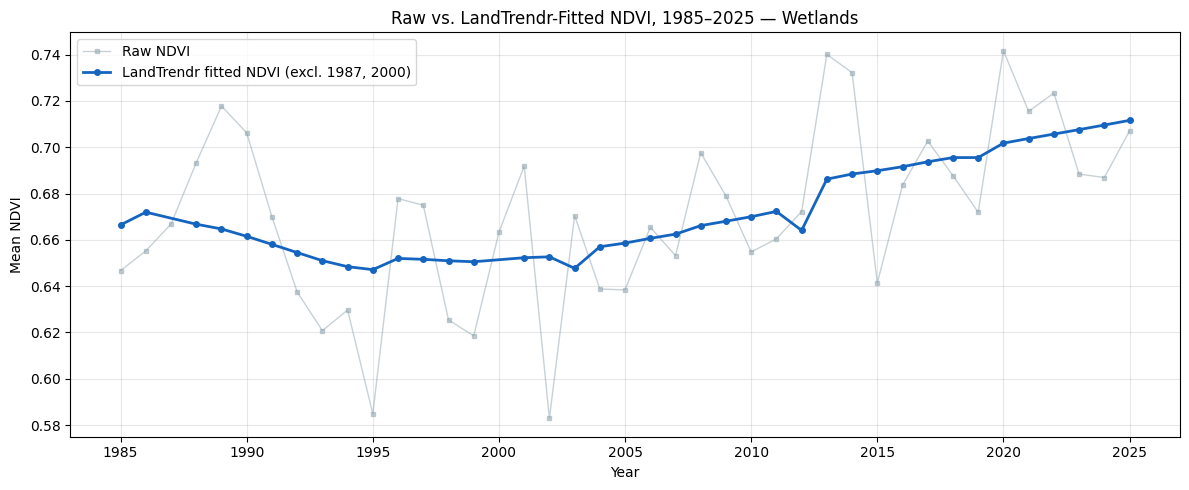

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Raw — all 41 years
plt.plot(years_watershed_list, mean_ndvi_wetland, marker='s', markersize=3,
         linewidth=1, color='#90A4AE', alpha=0.5, label='Raw NDVI')

# Fitted — 39 years (no 1987, 2000)
plt.plot(years_check_excl, mean_ndvi_fitted_wetland_excl, marker='o', markersize=4,
         linewidth=2, color='#1565C0', label='LandTrendr fitted NDVI (excl. 1987, 2000)')

plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.title('Raw vs. LandTrendr-Fitted NDVI, 1985–2025 — Wetlands')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ndvi_timeseries_wetland_raw_vs_fitted_excl.png', dpi=150)
plt.show()

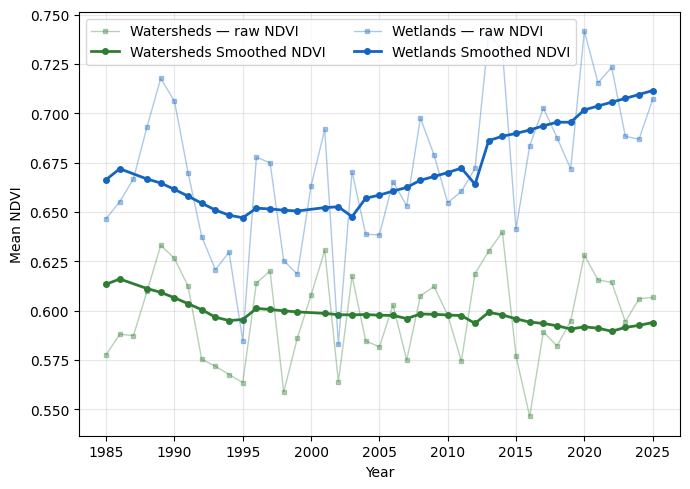

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Watersheds
plt.plot(years_watershed_list, mean_ndvi_watershed, marker='s', markersize=3,
         linewidth=1, color='#2E7D32', alpha=0.35, label='Watersheds — raw NDVI')
plt.plot(years_check_excl, mean_ndvi_fitted_excl, marker='o', markersize=4,
         linewidth=2, color='#2E7D32', label='Watersheds Smoothed NDVI')

# Wetlands
plt.plot(years_wetland_list, mean_ndvi_wetland, marker='s', markersize=3,
         linewidth=1, color='#1565C0', alpha=0.35, label='Wetlands — raw NDVI')
plt.plot(years_check_excl, mean_ndvi_fitted_wetland_excl, marker='o', markersize=4,
         linewidth=2, color='#1565C0', label='Wetlands Smoothed NDVI')

plt.xlabel('Year')
plt.ylabel('Mean NDVI')
#plt.title('Raw vs. LandTrendr-Fitted NDVI, 1985–2025 — Watersheds and Wetlands\n(fitted excludes 1987, 2000)')
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ndvi_timeseries_watershed_wetland_raw_vs_fitted_excl.png', dpi=150)
plt.show()

In [85]:
# ============================================
# Animated GIF of LandTrendr-fitted NDVI — 39 years (no 1987, 2000)
# ============================================
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

def update(frame_year):
    ax.clear()
    band_name = f'NDVI_fitted_{frame_year}'
    thumb_url = fitted_saved_excl.select(band_name).getThumbURL({
        'min': -0.2,
        'max': 0.9,
        'palette': ['brown', 'yellow', 'green', 'darkgreen'],
        'dimensions': 800,
        'region': clippedWatershed_geom,
    })
    response = requests.get(thumb_url)
    img = Image.open(BytesIO(response.content))
    ax.imshow(img)
    ax.set_title(f'LandTrendr-Fitted NDVI — {frame_year}')
    ax.axis('off')

ani = animation.FuncAnimation(fig, update, frames=years_check_excl, interval=300)
ani.save('ndvi_fitted_animation_excl1987_2000.gif', writer='pillow', dpi=150)
plt.close(fig)   # stops the empty figure from re-drawing after the cell finishes
print('Animation saved to ndvi_fitted_animation_excl1987_2000.gif')

Animation saved to ndvi_fitted_animation_excl1987_2000.gif


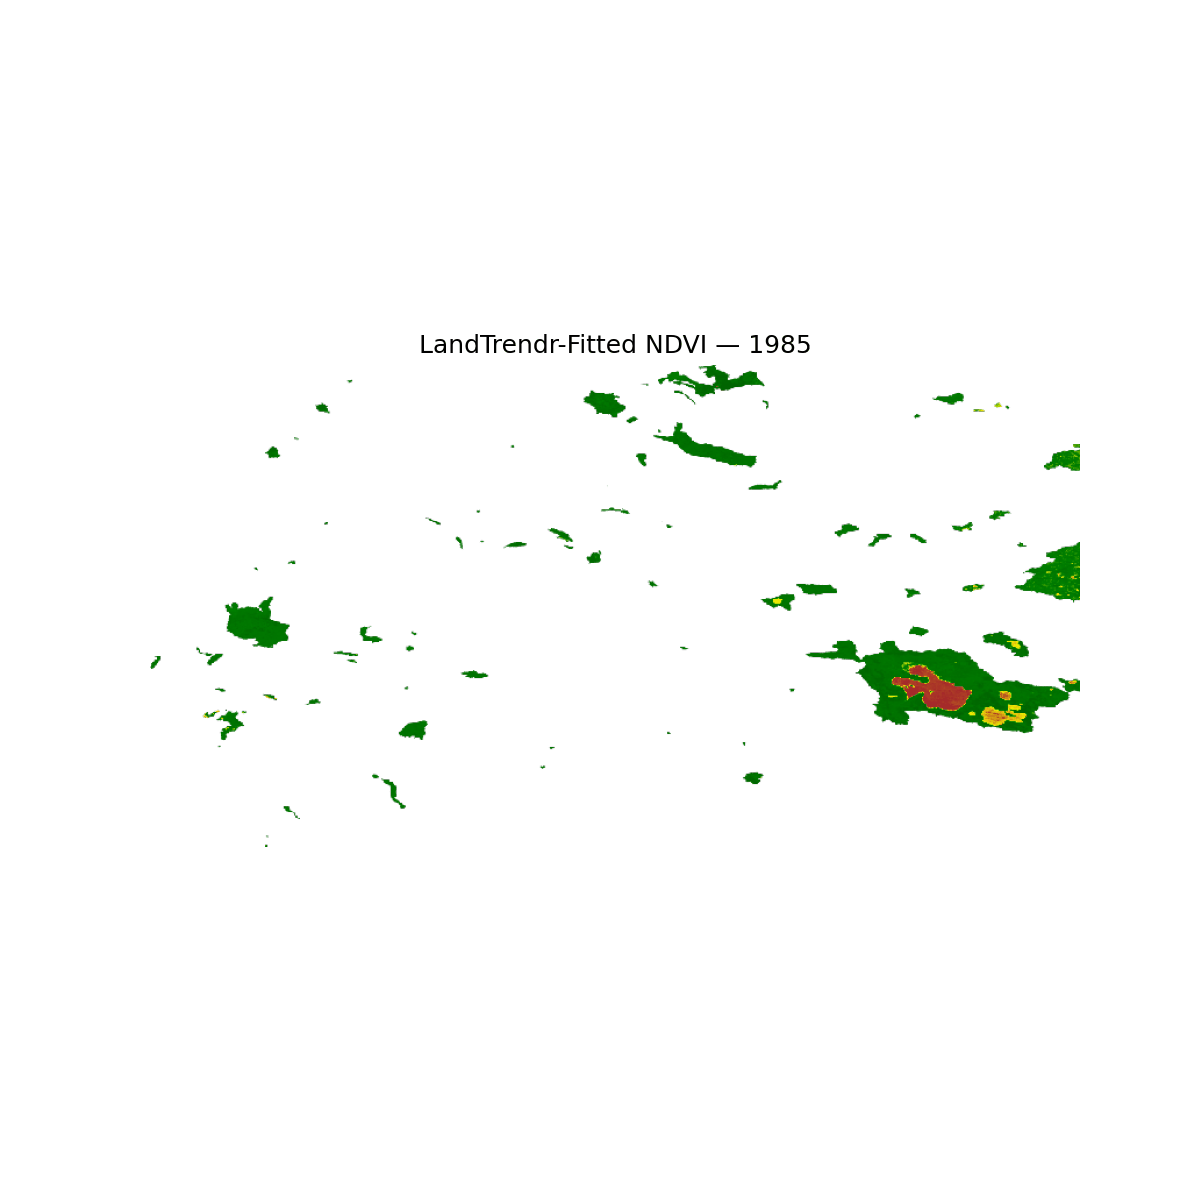

In [87]:
from IPython.display import Image as IPImage
IPImage(filename='/content/ndvi_fitted_animation_excl1987_2000.gif')

In [95]:
# ============================================
# Combined animation: time series (left) + NDVI map (right), synced by year
# ============================================
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

MAP_IMAGE  = fitted_saved_excl        # asset to show on the map
MAP_REGION = clippedWatershed_geom    # region for the map thumbnails
anim_years = years_check_excl         # 39 years (no 1987, 2000)

# --------------------------------------------
# 1. Download all map frames once (faster than fetching inside the animation)
# --------------------------------------------
frames = {}
for y in anim_years:
    url = MAP_IMAGE.select(f'NDVI_fitted_{y}').getThumbURL({
        'min': -0.2, 'max': 0.9,
        'palette': ['brown', 'yellow', 'green', 'darkgreen'],
        'dimensions': 1000,
        'region': MAP_REGION,
    })
    frames[y] = np.array(Image.open(BytesIO(requests.get(url).content)))
    print(y, 'downloaded')

# Lookups so each frame can find the value for its year
ws_fit = dict(zip(years_check_excl, mean_ndvi_fitted_excl))
wl_fit = dict(zip(years_check_excl, mean_ndvi_fitted_wetland_excl))

# --------------------------------------------
# 2. Figure: static time series + empty map
# --------------------------------------------
fig, (ax_ts, ax_map) = plt.subplots(1, 2, figsize=(12, 6),
                                    gridspec_kw={'width_ratios': [1.2, 1]})

# Time series (drawn once)
ax_ts.plot(years_watershed_list, mean_ndvi_watershed, marker='s', markersize=3,
           linewidth=1, color='#2E7D32', alpha=0.35, label='Watersheds — raw NDVI')
ax_ts.plot(years_check_excl, mean_ndvi_fitted_excl, marker='o', markersize=4,
           linewidth=2, color='#2E7D32', label='Watersheds — smoothed NDVI')
ax_ts.plot(years_wetland_list, mean_ndvi_wetland, marker='s', markersize=3,
           linewidth=1, color='#1565C0', alpha=0.35, label='Wetlands — raw NDVI')
ax_ts.plot(years_check_excl, mean_ndvi_fitted_wetland_excl, marker='o', markersize=4,
           linewidth=2, color='#1565C0', label='Wetlands — smoothed NDVI')
ax_ts.set_xlabel('Year')
ax_ts.set_ylabel('Mean NDVI')
ax_ts.grid(True, alpha=0.3)
ax_ts.legend(ncol=2, fontsize=9, loc='upper left')

# Moving elements: vertical line, highlight rings, year label
vline = ax_ts.axvline(anim_years[0], color='red', linewidth=1.5, linestyle='--')
ws_dot, = ax_ts.plot([], [], 'o', ms=12, mfc='none', mec='red', mew=2)
wl_dot, = ax_ts.plot([], [], 'o', ms=12, mfc='none', mec='red', mew=2)
year_txt = ax_ts.text(0.98, 0.04, '', transform=ax_ts.transAxes, ha='right',
                      fontsize=16, fontweight='bold', color='red')

# Map panel
map_img = ax_map.imshow(frames[anim_years[0]])
ax_map.axis('off')
map_title = ax_map.set_title('')

fig.suptitle('LandTrendr-Smoothed NDVI, 1985–2025 (excl. 1987, 2000)', fontsize=14)
plt.tight_layout()

# --------------------------------------------
# 3. Per-frame update: move the line/markers and swap the map
# --------------------------------------------
def update(year):
    vline.set_xdata([year, year])
    ws_dot.set_data([year], [ws_fit[year]])
    wl_dot.set_data([year], [wl_fit[year]])
    year_txt.set_text(str(year))
    map_img.set_data(frames[year])
    map_title.set_text(f'LandTrendr-Fitted NDVI — {year}')
    return vline, ws_dot, wl_dot, year_txt, map_img, map_title

ani = animation.FuncAnimation(fig, update, frames=anim_years, interval=400)
ani.save('ndvi_timeseries_map_animation.gif', writer='pillow', dpi=120)
plt.close(fig)
print('Saved ndvi_timeseries_map_animation.gif')

1985 downloaded
1986 downloaded
1988 downloaded
1989 downloaded
1990 downloaded
1991 downloaded
1992 downloaded
1993 downloaded
1994 downloaded
1995 downloaded
1996 downloaded
1997 downloaded
1998 downloaded
1999 downloaded
2001 downloaded
2002 downloaded
2003 downloaded
2004 downloaded
2005 downloaded
2006 downloaded
2007 downloaded
2008 downloaded
2009 downloaded
2010 downloaded
2011 downloaded
2012 downloaded
2013 downloaded
2014 downloaded
2015 downloaded
2016 downloaded
2017 downloaded
2018 downloaded
2019 downloaded
2020 downloaded
2021 downloaded
2022 downloaded
2023 downloaded
2024 downloaded
2025 downloaded
Saved ndvi_timeseries_map_animation.gif


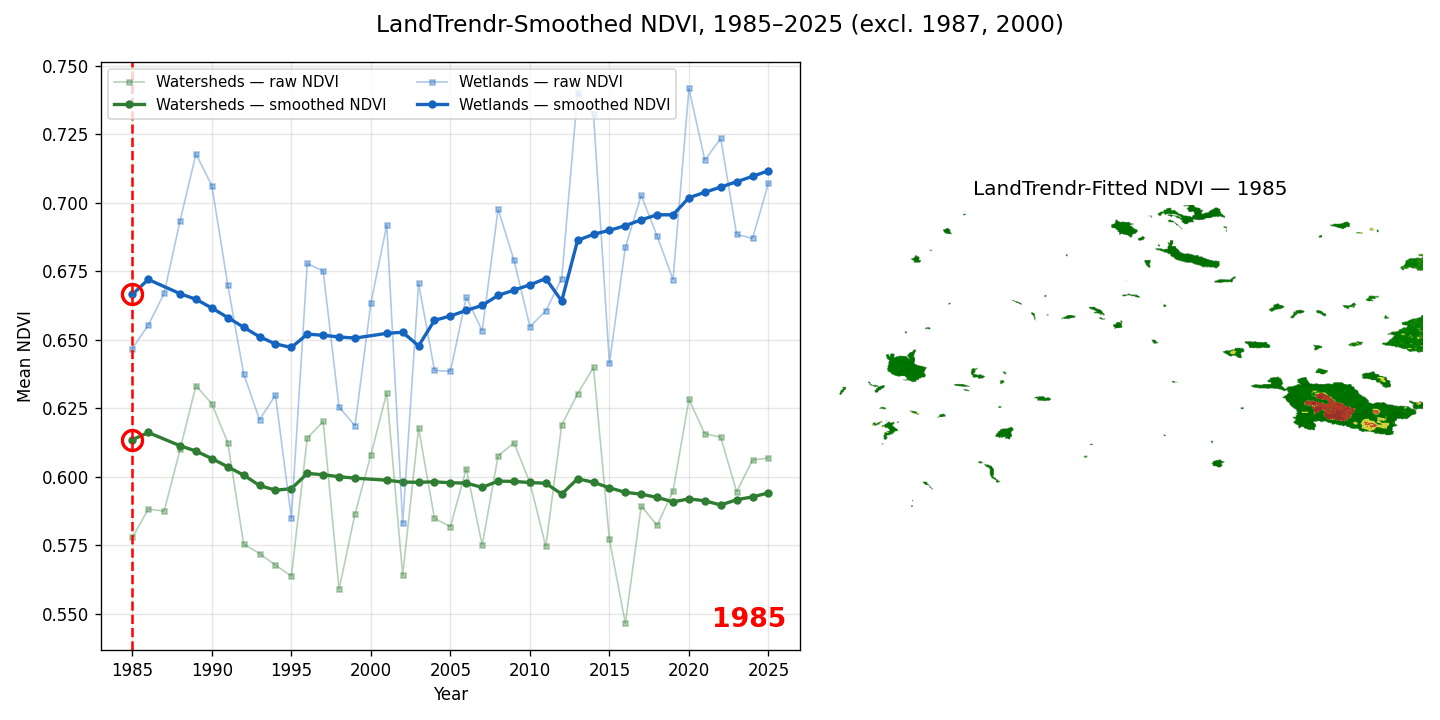

In [97]:
from IPython.display import Image as IPImage
IPImage(filename='/content/ndvi_timeseries_map_animation.gif')

In [33]:
# %% ============================================
# Per-watershed NDVI trends (121 watersheds), 1985–2025
# Run after the LandTrendr-fitted plotting cell.
# Cells are separated by "# %%" — paste each into its own notebook cell.
# ============================================
 
# !pip install pymannkendall geopandas --break-system-packages   # uncomment if needed
 
import time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymannkendall as mk
from scipy.stats import theilslopes
from statsmodels.stats.multitest import multipletests
 
DRIVE_FOLDER = 'OSM_watershed_trends-1987-2000Excluded'   # Drive folder for the CSV export
EXCLUDE_YEARS = []                      # e.g. [1987, 2000] to drop those years
MIN_YEARS = 20                          # min valid years needed to test a trend
ALPHA = 0.05             # 'ndvi_fit' = LandTrendr-fitted NDVI, 'ndvi' = raw NDVI

In [34]:
# %% ============================================
# STEP 1: Give every watershed a stable ID
# ============================================
 
print('Watershed attribute fields:', watersheds.first().propertyNames().getInfo())
 
# Set this to the watershed's own ID field if it has one (e.g. 'WS_ID').
# Leave as None to number the watersheds 0–120.
ID_FIELD = None
 
if ID_FIELD:
    ws_fc = watersheds.map(lambda f: f.set('ws_id', f.get(ID_FIELD)))
else:
    ws_list = watersheds.toList(watersheds.size())
    ws_fc = ee.FeatureCollection(
        ee.List.sequence(0, watersheds.size().subtract(1)).map(
            lambda i: ee.Feature(ws_list.get(i)).set('ws_id', i)
        )
    )
 
# Keep only the ID and the area, so the CSV stays small
ws_fc = ws_fc.map(lambda f: ee.Feature(f.geometry(), {
    'ws_id': f.get('ws_id'),
    'area_km2': f.geometry().area(maxError=1).divide(1e6)
}))
 
print('Watersheds with IDs:', ws_fc.size().getInfo())
 
# Preview the attribute table (geometry dropped so it loads fast)
preview = ws_fc.limit(5).map(lambda f: f.setGeometry(None)).getInfo()
pd.DataFrame([f['properties'] for f in preview['features']])

Watershed attribute fields: ['Status', 'LandLng', 'Mt_Sttn', 'LandLat', 'DrainID', 'LandWPT', 'Drft_Cl', 'BatchDone', 'Shape_Leng', 'SiteCod', 'Year', 'Phtplts', 'WQ_W___', 'Shape_Area', 'Long', 'HydroID', 'WtlndCl', 'StatnNm', 'Lat', 'Trn____', 'system:index']
Watersheds with IDs: 121


,area_km2,ws_id
0,0.477790,0
1,0.303625,1
2,0.892298,2
3,1.003228,3
4,9.170204,4


In [53]:
# %% ============================================
# STEP 2: Fitted NDVI as one multiband image (one band per year)
# ============================================

years = [y for y in range(start_year, end_year + 1) if y not in [1987, 2000]]

fitted_stack = fitted_saved_excl.select(
    [f'NDVI_fitted_{y}' for y in years],
    [f'FIT_{y}' for y in years]
)

bands = fitted_stack.bandNames().getInfo()
print(f'Fitted stack: {len(bands)} bands, {bands[0]} … {bands[-1]}')   # 39 bands

Fitted stack: 39 bands, FIT_1985 … FIT_2025


In [ ]:
# %% ============================================
# STEP 3: Mean fitted NDVI per watershed per year → export CSV to Drive
# ============================================
 
#fitted_table = fitted_stack.reduceRegions(
#    collection=ws_fc, reducer=ee.Reducer.mean(), scale=30, tileScale=8
#)
 
#fit_cols = ['ws_id', 'area_km2'] + [f'FIT_{y}' for y in years]
 
#task_fit = ee.batch.Export.table.toDrive(
#    collection=fitted_table.select(fit_cols, None, False),
#    description='watershed_ndvi_fitted_1985_2025',
#    folder=DRIVE_FOLDER,
#    fileFormat='CSV',
#    selectors=fit_cols
#)
#task_fit.start()
 
#while task_fit.active():
#    print('fitted:', task_fit.status()['state'])
#    time.sleep(60)
 
#print('fitted final:', task_fit.status()['state'])

fitted: READY
fitted final: COMPLETED


In [55]:
# %% ============================================
# STEP 4: Read the CSV and reshape to one row per watershed-year
# ============================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

folder = '/content/drive/MyDrive/OSM_watershed_trends-1987-2000Excluded'

csv_files = glob.glob(f'{folder}/*.csv')
print('CSV files in folder:', csv_files)

fit_path = csv_files[0]
fit_df = pd.read_csv(fit_path)
print(fit_path, fit_df.shape)

fit_long = fit_df.melt(id_vars=['ws_id', 'area_km2'],
                       value_vars=[f'FIT_{y}' for y in years],
                       var_name='year', value_name='ndvi_fit')
fit_long['year'] = fit_long['year'].str[-4:].astype(int)

Mounted at /content/drive
CSV files in folder: ['/content/drive/MyDrive/OSM_watershed_trends-1987-2000Excluded/watershed_ndvi_fitted_1985_2025.csv']
/content/drive/MyDrive/OSM_watershed_trends-1987-2000Excluded/watershed_ndvi_fitted_1985_2025.csv (121, 41)


In [56]:
# %% ============================================
# STEP 5: Drop excluded years and missing values
# ============================================
 
clean = fit_long[
    (~fit_long['year'].isin(EXCLUDE_YEARS)) &
    (fit_long['ndvi_fit'].notna())
].copy()
 
print('Watershed-years kept:', len(clean), 'of', len(fit_long))
print('Valid years per watershed (min / median / max):',
      clean.groupby('ws_id').size().agg(['min', 'median', 'max']).tolist())

Watershed-years kept: 4719 of 4719
Valid years per watershed (min / median / max): [39.0, 39.0, 39.0]


In [57]:
# %% ============================================
# STEP 6: Trend test per watershed on fitted NDVI
# Modified Mann–Kendall (Hamed–Rao) for significance, Theil–Sen for slope (NDVI/yr)
# ============================================
 
rows = []
for ws_id, g in clean.groupby('ws_id'):
    g = g.sort_values('year')
    n = len(g)
    if n < MIN_YEARS:
        rows.append({'ws_id': ws_id, 'n_years': n, 'sen_slope': np.nan,
                     'mk_p': np.nan, 'mk_tau': np.nan})
        continue
 
    mk_res = mk.hamed_rao_modification_test(g['ndvi_fit'].values)
    slope, intercept, lo, hi = theilslopes(g['ndvi_fit'].values, g['year'].values)
 
    rows.append({
        'ws_id': ws_id,
        'n_years': n,
        'sen_slope': slope,               # NDVI change per year
        'sen_slope_lo95': lo,
        'sen_slope_hi95': hi,
        'change_1985_2025': slope * (end_year - start_year),
        'mk_tau': mk_res.Tau,
        'mk_p': mk_res.p,
    })
 
trends = pd.DataFrame(rows)
 
# FDR correction across all tested watersheds
tested = trends['mk_p'].notna()
trends.loc[tested, 'p_fdr'] = multipletests(trends.loc[tested, 'mk_p'], method='fdr_bh')[1]
 
def classify(r):
    if pd.isna(r['p_fdr']):
        return 'Insufficient data'
    if r['p_fdr'] < ALPHA and r['sen_slope'] > 0:
        return 'Significant increase'
    if r['p_fdr'] < ALPHA and r['sen_slope'] < 0:
        return 'Significant decrease'
    return 'No significant trend'
 
trends['trend_class'] = trends.apply(classify, axis=1)
trends = trends.merge(fit_df[['ws_id', 'area_km2']], on='ws_id')
 
trends.to_csv('watershed_ndvi_trends.csv', index=False)
trends.head()

,ws_id,n_years,sen_slope,sen_slope_lo95,sen_slope_hi95,change_1985_2025,mk_tau,mk_p,p_fdr,trend_class,area_km2
0,0.0,39,0.001406,0.001276,0.001493,0.056233,0.916329,0.000029,0.000153,Significant increase,0.477790
1,1.0,39,0.000913,0.000775,0.001315,0.036529,0.735493,0.002110,0.004479,Significant increase,0.303625
2,2.0,39,0.000383,-0.000026,0.000787,0.015314,0.211876,0.385763,0.428232,No significant trend,0.892298
3,3.0,39,0.001524,0.001270,0.001634,0.060944,0.622132,0.005624,0.010311,Significant increase,1.003228
4,4.0,39,0.001168,0.000674,0.001544,0.046732,0.473684,0.046043,0.067122,No significant trend,9.170204


                      n_watersheds  percent  area_km2
trend_class                                          
Significant increase            71     58.7     795.0
No significant trend            41     33.9     306.0
Significant decrease             9      7.4     801.0
Increase (uncorrected)    73
No trend (uncorrected)    38
Decrease (uncorrected)    10
Name: count, dtype: int64


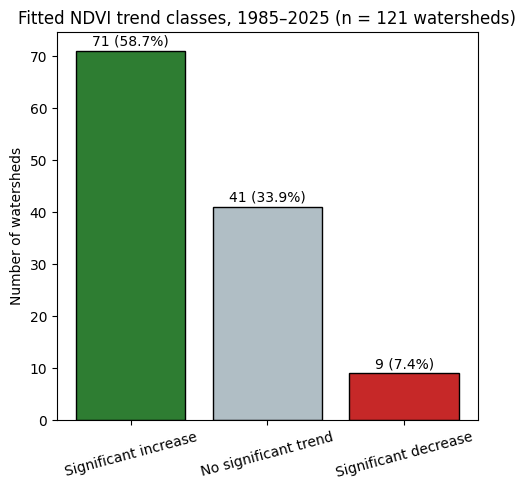

In [92]:
# %% ============================================
# STEP 7: Summary — counts, percentages, bar chart
# ============================================
 
order = ['Significant increase', 'No significant trend', 'Significant decrease', 'Insufficient data']
colors = {'Significant increase': '#2E7D32', 'No significant trend': '#B0BEC5',
          'Significant decrease': '#C62828', 'Insufficient data': '#FFFFFF'}
 
summary = (trends['trend_class'].value_counts()
           .reindex(order).dropna().astype(int).to_frame('n_watersheds'))
summary['percent'] = (100 * summary['n_watersheds'] / len(trends)).round(1)
summary['area_km2'] = trends.groupby('trend_class')['area_km2'].sum().reindex(summary.index).round(0)
print(summary)
 
# Same classification without the FDR correction, for reference
uncorrected = np.select(
    [(trends['mk_p'] < ALPHA) & (trends['sen_slope'] > 0),
     (trends['mk_p'] < ALPHA) & (trends['sen_slope'] < 0)],
    ['Increase (uncorrected)', 'Decrease (uncorrected)'], 'No trend (uncorrected)')
print(pd.Series(uncorrected).value_counts())
 
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(summary.index, summary['n_watersheds'],
       color=[colors[c] for c in summary.index], edgecolor='black')
for i, (n, p) in enumerate(zip(summary['n_watersheds'], summary['percent'])):
    ax.text(i, n + 1, f'{n} ({p}%)', ha='center')
ax.set_ylabel('Number of watersheds')
ax.set_title(f'Fitted NDVI trend classes, {start_year}–{end_year} (n = {len(trends)} watersheds)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('watershed_trend_class_counts.png', dpi=150)
plt.show()

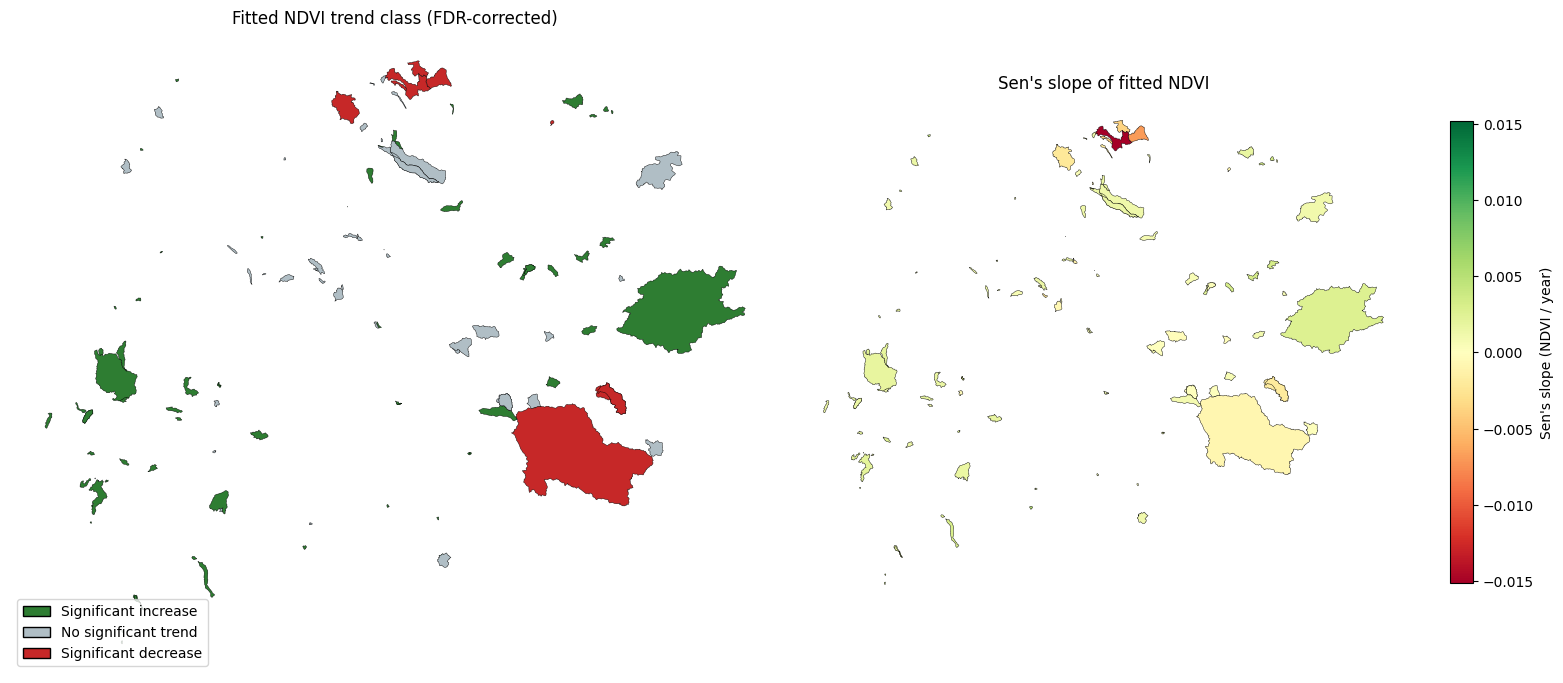

In [59]:
# %% ============================================
# STEP 8: Maps — trend class and Sen's slope
# ============================================
 
import geopandas as gpd
 
# Simplify geometries before download (121 polygons, 100 m tolerance is plenty for a map)
ws_simple = ws_fc.map(lambda f: f.simplify(100))
gdf = geemap.ee_to_gdf(ws_simple).merge(trends.drop(columns='area_km2'), on='ws_id')
 
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
 
present = [c for c in order if c in gdf['trend_class'].values]
for cls in present:
    gdf[gdf['trend_class'] == cls].plot(ax=axes[0], color=colors[cls],
                                        edgecolor='black', linewidth=0.3)
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, fc=colors[c], ec='black') for c in present],
               labels=present, loc='lower left')
axes[0].set_title('Fitted NDVI trend class (FDR-corrected)')
axes[0].axis('off')
 
lim = np.nanmax(np.abs(gdf['sen_slope']))
gdf.plot(column='sen_slope', ax=axes[1], cmap='RdYlGn', vmin=-lim, vmax=lim,
         edgecolor='black', linewidth=0.3, legend=True,
         legend_kwds={'label': "Sen's slope (NDVI / year)", 'shrink': 0.6})
axes[1].set_title("Sen's slope of fitted NDVI")
axes[1].axis('off')
 
plt.tight_layout()
plt.savefig('watershed_trend_maps.png', dpi=150)
plt.show()

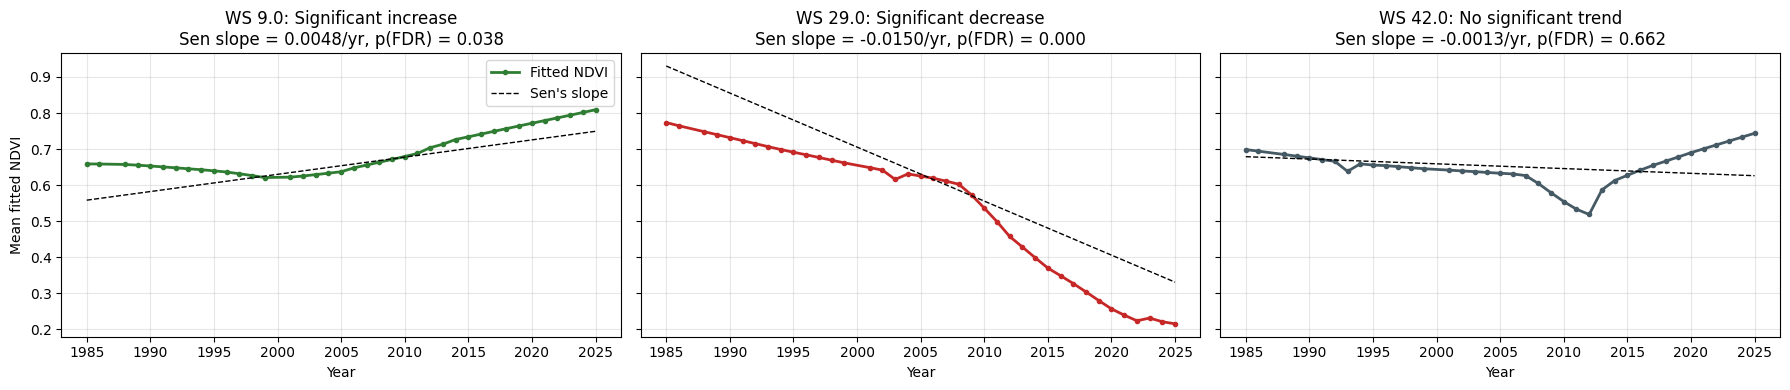

In [44]:
# %% ============================================
# STEP 9: Fitted NDVI series for example watersheds, with Sen's slope line
# ============================================
 
examples = []
for cls in ['Significant increase', 'Significant decrease', 'No significant trend']:
    ids = trends.loc[trends['trend_class'] == cls].sort_values('sen_slope')['ws_id']
    if len(ids):
        examples.append((cls, ids.iloc[-1] if cls == 'Significant increase' else ids.iloc[0]))
 
fig, axes = plt.subplots(1, len(examples), figsize=(6 * len(examples), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, (cls, ws) in zip(axes, examples):
    g = clean[clean['ws_id'] == ws].sort_values('year')
    t = trends[trends['ws_id'] == ws].iloc[0]
    line_color = colors[cls] if cls != 'No significant trend' else '#455A64'
 
    slope, intercept, _, _ = theilslopes(g['ndvi_fit'].values, g['year'].values)
    ax.plot(g['year'], g['ndvi_fit'], 'o-', color=line_color, ms=3, lw=2, label='Fitted NDVI')
    ax.plot(g['year'], intercept + slope * g['year'], '--', color='black', lw=1, label="Sen's slope")
 
    ax.set_title(f'WS {ws}: {cls}\nSen slope = {t.sen_slope:.4f}/yr, p(FDR) = {t.p_fdr:.3f}')
    ax.set_xlabel('Year')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Mean fitted NDVI')
axes[0].legend()
plt.tight_layout()
plt.savefig('watershed_trend_examples.png', dpi=150)
plt.show()

In [60]:
import geopandas as gpd

ws_simple = ws_fc.map(lambda f: f.simplify(100))
gdf = geemap.ee_to_gdf(ws_simple).merge(trends.drop(columns='area_km2'), on='ws_id')

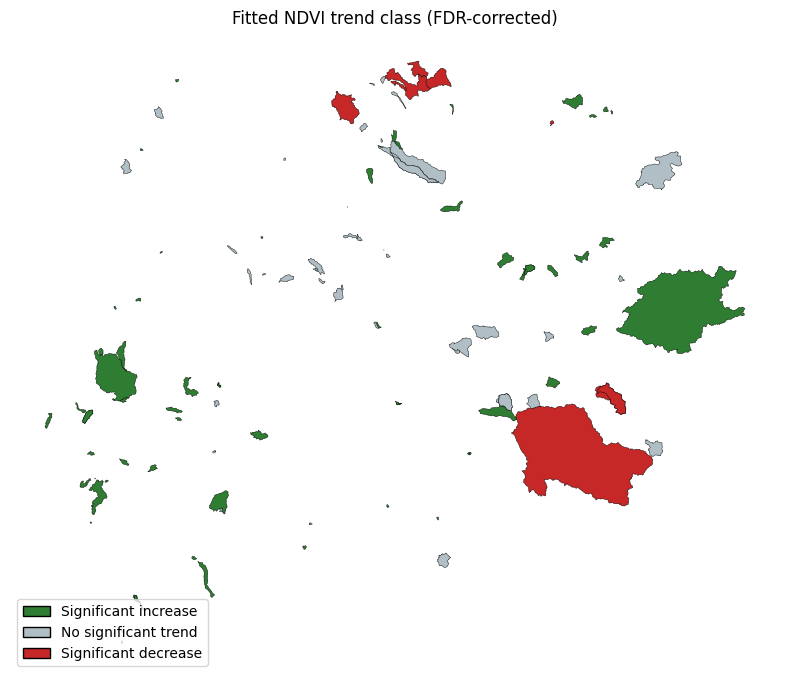

In [61]:
fig, ax = plt.subplots(figsize=(8, 8))

present = [c for c in order if c in gdf['trend_class'].values]
for cls in present:
    gdf[gdf['trend_class'] == cls].plot(ax=ax, color=colors[cls],
                                        edgecolor='black', linewidth=0.3)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, fc=colors[c], ec='black') for c in present],
          labels=present, loc='lower left')
ax.set_title('Fitted NDVI trend class (FDR-corrected)')
ax.axis('off')

plt.tight_layout()
plt.savefig('watershed_trend_class_map.png', dpi=150)
plt.show()

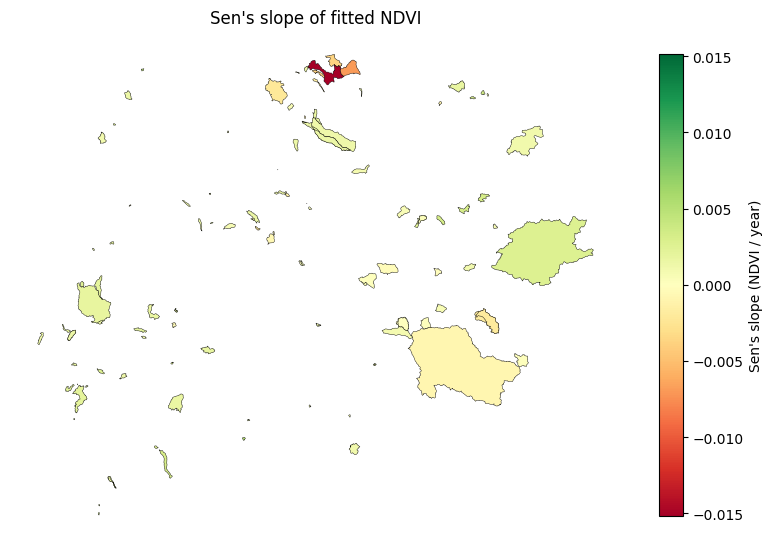

In [62]:
fig, ax = plt.subplots(figsize=(8, 8))

lim = np.nanmax(np.abs(gdf['sen_slope']))
gdf.plot(column='sen_slope', ax=ax, cmap='RdYlGn', vmin=-lim, vmax=lim,
         edgecolor='black', linewidth=0.3, legend=True,
         legend_kwds={'label': "Sen's slope (NDVI / year)", 'shrink': 0.6})
ax.set_title("Sen's slope of fitted NDVI")
ax.axis('off')

plt.tight_layout()
plt.savefig('watershed_sen_slope_map.png', dpi=150)
plt.show()

In [63]:
# %% ============================================
# Per-wetland trends in LandTrendr-fitted NDVI (121 wetlands), 1985–2025
# Same workflow as watershed_ndvi_trends.py, applied to the wetland polygons.
# Cells are separated by "# %%" — paste each into its own notebook cell.
# ============================================
 
# !pip install pymannkendall geopandas --break-system-packages   # uncomment if needed
 
import time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymannkendall as mk
from scipy.stats import theilslopes
from statsmodels.stats.multitest import multipletests
 
DRIVE_FOLDER = 'OSM_wetland_trends'     # Drive folder for the CSV export
EXCLUDE_YEARS = []                      # e.g. [1987, 2000] to drop those years
MIN_YEARS = 20                          # min valid years needed to test a trend
ALPHA = 0.05

In [49]:
# %% ============================================
# STEP 1: Give every wetland a stable ID
# ============================================
 
print('Wetland attribute fields:', wetlands.first().propertyNames().getInfo())
 
# Set this to the wetland's own ID field if it has one (e.g. 'WL_ID').
# Leave as None to number the wetlands 0–120.
ID_FIELD = None
 
if ID_FIELD:
    wl_fc = wetlands.map(lambda f: f.set('wl_id', f.get(ID_FIELD)))
else:
    wl_list = wetlands.toList(wetlands.size())
    wl_fc = ee.FeatureCollection(
        ee.List.sequence(0, wetlands.size().subtract(1)).map(
            lambda i: ee.Feature(wl_list.get(i)).set('wl_id', i)
        )
    )
 
# Keep only the ID and the area, so the CSV stays small
wl_fc = wl_fc.map(lambda f: ee.Feature(f.geometry(), {
    'wl_id': f.get('wl_id'),
    'area_km2': f.geometry().area(maxError=1).divide(1e6)
}))
 
print('Wetlands with IDs:', wl_fc.size().getInfo())
 
# Preview the attribute table (geometry dropped so it loads fast)
preview = wl_fc.limit(5).map(lambda f: f.setGeometry(None)).getInfo()
pd.DataFrame([f['properties'] for f in preview['features']])

Wetland attribute fields: ['Status', 'LandLng', 'Mt_Sttn', 'LandLat', 'LandWPT', 'Drft_Cl', 'SiteCod', 'Year', 'Phtplts', 'WQ_W___', 'Long', 'WtlndCl', 'StatnNm', 'Lat', 'Trn____', 'system:index']
Wetlands with IDs: 121


,area_km2,wl_id
0,0.163930,0
1,0.121206,1
2,0.006673,2
3,2.462031,3
4,0.037310,4


In [64]:
# %% ============================================
# STEP 2: Fitted NDVI as one multiband image (one band per year)
# ============================================

# Take the years directly from the asset's band names (39 years, no 1987/2000)
asset_bands = fitted_saved_excl.bandNames().getInfo()
years = [int(b.split('_')[-1]) for b in asset_bands]

fitted_stack = fitted_saved_excl.select(
    [f'NDVI_fitted_{y}' for y in years],
    [f'FIT_{y}' for y in years]
)

bands = fitted_stack.bandNames().getInfo()
print(f'Fitted stack: {len(bands)} bands, {bands[0]} … {bands[-1]}')   # 39 bands
print('Missing years:', [y for y in range(start_year, end_year + 1) if y not in years])

Fitted stack: 39 bands, FIT_1985 … FIT_2025
Missing years: [1987, 2000]


In [ ]:
# %% ============================================
# STEP 3: Mean fitted NDVI per wetland per year → export CSV to Drive
# ============================================
 
#fitted_table = fitted_stack.reduceRegions(
#    collection=wl_fc, reducer=ee.Reducer.mean(), scale=30, tileScale=8
#)
 
#fit_cols = ['wl_id', 'area_km2'] + [f'FIT_{y}' for y in years]
 
#task_fit = ee.batch.Export.table.toDrive(
#    collection=fitted_table.select(fit_cols, None, False),
#    description='wetland_ndvi_fitted_1985_2025',
#    folder=,
#    fileFormat='CSV',
#    selectors=fit_cols
#)
#task_fit.start()
 
#while task_fit.active():
 #   print('fitted:', task_fit.status()['state'])
  #  time.sleep(60)
 
#print('fitted final:', task_fit.status()['state'])

fitted: READY
fitted final: COMPLETED


In [70]:
# %% ============================================
# STEP 4: Read the CSV and reshape to one row per wetland-year
# ============================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

matches = glob.glob('/content/drive/MyDrive/**/wetland_ndvi_fitted_1985_2025.csv', recursive=True)
for p in matches:
    print(p, pd.read_csv(p).shape)

# Pick the copy whose year columns match `years` (39 years, no 1987/2000)
expected_cols = {f'FIT_{y}' for y in years}
fit_path = next(p for p in matches
                if {c for c in pd.read_csv(p, nrows=0).columns if c.startswith('FIT_')} == expected_cols)

fit_df = pd.read_csv(fit_path)
print('Using:', fit_path, fit_df.shape)

fit_long = fit_df.melt(id_vars=['wl_id', 'area_km2'],
                       value_vars=[f'FIT_{y}' for y in years],
                       var_name='year', value_name='ndvi_fit')
fit_long['year'] = fit_long['year'].str[-4:].astype(int)

Mounted at /content/drive
/content/drive/MyDrive/OSM_wetland_trends/wetland_ndvi_fitted_1985_2025.csv (121, 43)
/content/drive/MyDrive/OSM_watershed_trends-1987-2000Excluded/wetland_ndvi_fitted_1985_2025.csv (121, 41)
Using: /content/drive/MyDrive/OSM_watershed_trends-1987-2000Excluded/wetland_ndvi_fitted_1985_2025.csv (121, 41)


In [71]:
# %% ============================================
# STEP 5: Drop excluded years and missing values
# ============================================
 
clean = fit_long[
    (~fit_long['year'].isin(EXCLUDE_YEARS)) &
    (fit_long['ndvi_fit'].notna())
].copy()
 
print('Wetland-years kept:', len(clean), 'of', len(fit_long))
print('Valid years per wetland (min / median / max):',
      clean.groupby('wl_id').size().agg(['min', 'median', 'max']).tolist())

Wetland-years kept: 4719 of 4719
Valid years per wetland (min / median / max): [39.0, 39.0, 39.0]


In [72]:
# %% ============================================
# STEP 6: Trend test per wetland on fitted NDVI
# Modified Mann–Kendall (Hamed–Rao) for significance, Theil–Sen for slope (NDVI/yr)
# ============================================
 
rows = []
for wl_id, g in clean.groupby('wl_id'):
    g = g.sort_values('year')
    n = len(g)
    if n < MIN_YEARS:
        rows.append({'wl_id': wl_id, 'n_years': n, 'sen_slope': np.nan,
                     'mk_p': np.nan, 'mk_tau': np.nan})
        continue
 
    mk_res = mk.hamed_rao_modification_test(g['ndvi_fit'].values)
    slope, intercept, lo, hi = theilslopes(g['ndvi_fit'].values, g['year'].values)
 
    rows.append({
        'wl_id': wl_id,
        'n_years': n,
        'sen_slope': slope,               # NDVI change per year
        'sen_slope_lo95': lo,
        'sen_slope_hi95': hi,
        'change_1985_2025': slope * (end_year - start_year),
        'mk_tau': mk_res.Tau,
        'mk_p': mk_res.p,
    })
 
trends_wl = pd.DataFrame(rows)
 
# FDR correction across all tested wetlands
tested = trends_wl['mk_p'].notna()
trends_wl.loc[tested, 'p_fdr'] = multipletests(trends_wl.loc[tested, 'mk_p'], method='fdr_bh')[1]
 
def classify(r):
    if pd.isna(r['p_fdr']):
        return 'Insufficient data'
    if r['p_fdr'] < ALPHA and r['sen_slope'] > 0:
        return 'Significant increase'
    if r['p_fdr'] < ALPHA and r['sen_slope'] < 0:
        return 'Significant decrease'
    return 'No significant trend'
 
trends_wl['trend_class'] = trends_wl.apply(classify, axis=1)
trends_wl = trends_wl.merge(fit_df[['wl_id', 'area_km2']], on='wl_id')
 
trends_wl.to_csv('wetland_ndvi_trends.csv', index=False)
trends_wl.head()

,wl_id,n_years,sen_slope,sen_slope_lo95,sen_slope_hi95,change_1985_2025,mk_tau,mk_p,p_fdr,trend_class,area_km2
0,0.0,39,-0.001875,-0.002641,-0.001118,-0.074981,-0.414305,0.102674,0.126771,No significant trend,0.163930
1,1.0,39,0.001074,0.000371,0.001606,0.042953,0.319838,0.204827,0.225310,No significant trend,0.121206
2,2.0,39,-0.000014,-0.000050,0.000019,-0.000541,-0.093117,0.354398,0.369674,No significant trend,0.006673
3,3.0,39,0.001629,0.001251,0.002086,0.065142,0.551957,0.023844,0.034760,Significant increase,2.462031
4,4.0,39,0.002710,0.002161,0.002919,0.108412,0.816464,0.000034,0.000160,Significant increase,0.037310


                      n_wetlands  percent  area_km2
trend_class                                        
Significant increase          86     71.1      50.5
No significant trend          32     26.4      14.0
Significant decrease           3      2.5       0.3
Increase (uncorrected)    87
No trend (uncorrected)    30
Decrease (uncorrected)     4
Name: count, dtype: int64


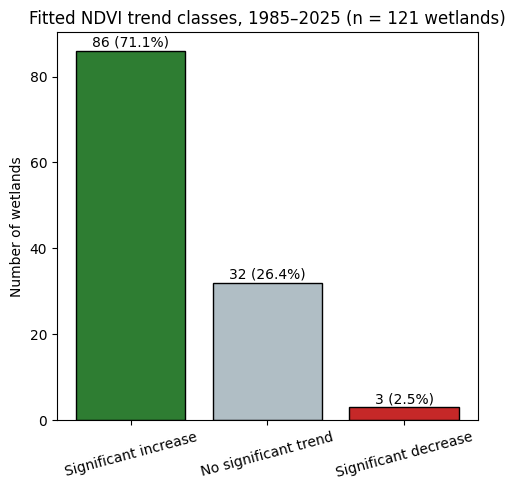

In [91]:
# %% ============================================
# STEP 7: Summary — counts, percentages, bar chart
# ============================================
 
order = ['Significant increase', 'No significant trend', 'Significant decrease', 'Insufficient data']
colors = {'Significant increase': '#2E7D32', 'No significant trend': '#B0BEC5',
          'Significant decrease': '#C62828', 'Insufficient data': '#FFFFFF'}
 
summary_wl = (trends_wl['trend_class'].value_counts()
              .reindex(order).dropna().astype(int).to_frame('n_wetlands'))
summary_wl['percent'] = (100 * summary_wl['n_wetlands'] / len(trends_wl)).round(1)
summary_wl['area_km2'] = (trends_wl.groupby('trend_class')['area_km2'].sum()
                          .reindex(summary_wl.index).round(1))
print(summary_wl)
 
# Same classification without the FDR correction, for reference
uncorrected = np.select(
    [(trends_wl['mk_p'] < ALPHA) & (trends_wl['sen_slope'] > 0),
     (trends_wl['mk_p'] < ALPHA) & (trends_wl['sen_slope'] < 0)],
    ['Increase (uncorrected)', 'Decrease (uncorrected)'], 'No trend (uncorrected)')
print(pd.Series(uncorrected).value_counts())
 
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(summary_wl.index, summary_wl['n_wetlands'],
       color=[colors[c] for c in summary_wl.index], edgecolor='black')
for i, (n, p) in enumerate(zip(summary_wl['n_wetlands'], summary_wl['percent'])):
    ax.text(i, n + 1, f'{n} ({p}%)', ha='center')
ax.set_ylabel('Number of wetlands')
ax.set_title(f'Fitted NDVI trend classes, {start_year}–{end_year} (n = {len(trends_wl)} wetlands)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('wetland_trend_class_counts.png', dpi=150)
plt.show()

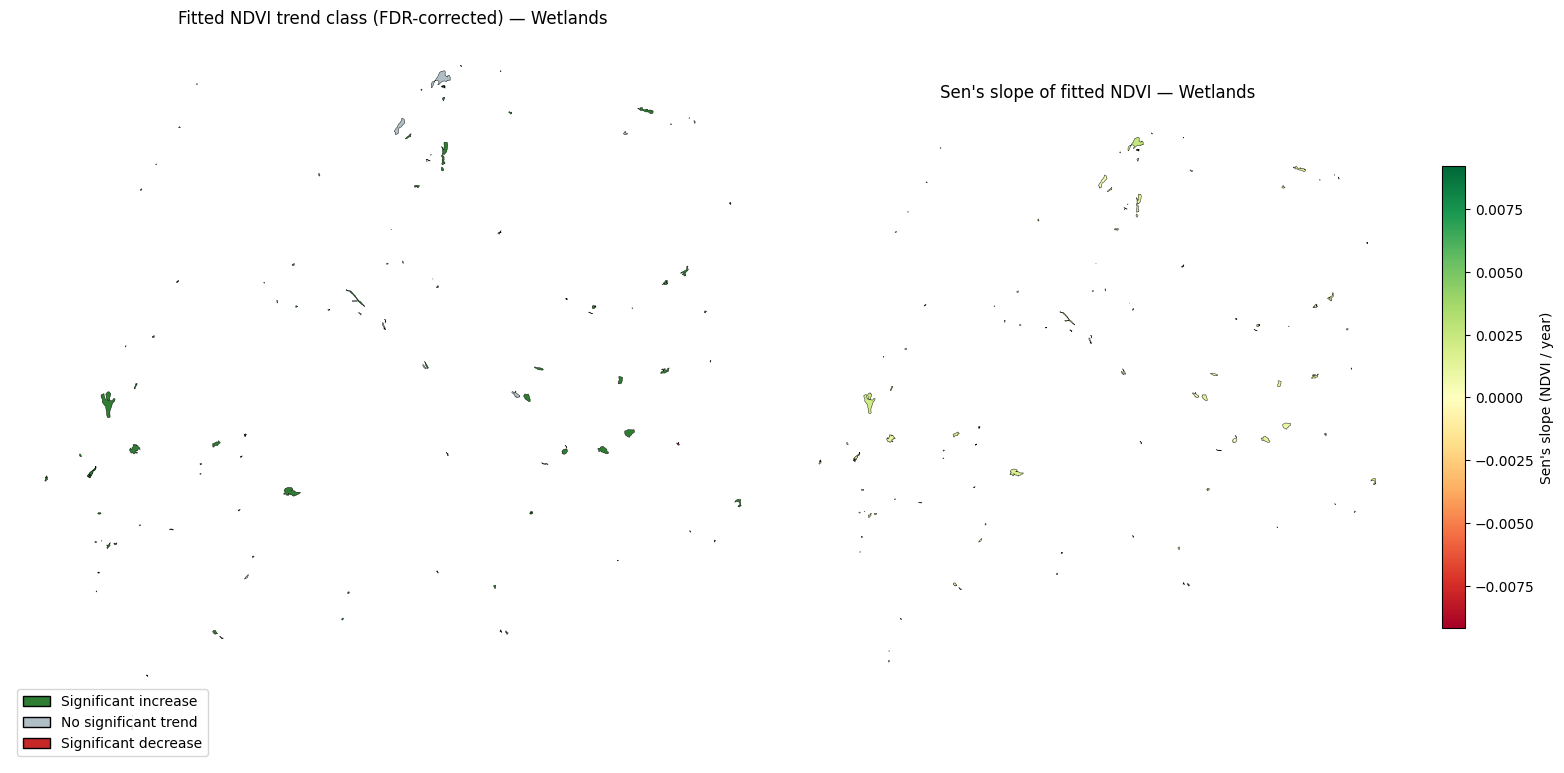

In [74]:
# %% ============================================
# STEP 8: Maps — trend class and Sen's slope
# ============================================
 
import geopandas as gpd
 
# Wetlands are smaller than watersheds, so simplify less (30 m = one Landsat pixel)
wl_simple = wl_fc.map(lambda f: f.simplify(30))
gdf_wl = geemap.ee_to_gdf(wl_simple).merge(trends_wl.drop(columns='area_km2'), on='wl_id')
 
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
 
present = [c for c in order if c in gdf_wl['trend_class'].values]
for cls in present:
    gdf_wl[gdf_wl['trend_class'] == cls].plot(ax=axes[0], color=colors[cls],
                                              edgecolor='black', linewidth=0.3)
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, fc=colors[c], ec='black') for c in present],
               labels=present, loc='lower left')
axes[0].set_title('Fitted NDVI trend class (FDR-corrected) — Wetlands')
axes[0].axis('off')
 
lim = np.nanmax(np.abs(gdf_wl['sen_slope']))
gdf_wl.plot(column='sen_slope', ax=axes[1], cmap='RdYlGn', vmin=-lim, vmax=lim,
            edgecolor='black', linewidth=0.3, legend=True,
            legend_kwds={'label': "Sen's slope (NDVI / year)", 'shrink': 0.6})
axes[1].set_title("Sen's slope of fitted NDVI — Wetlands")
axes[1].axis('off')
 
plt.tight_layout()
plt.savefig('wetland_trend_maps.png', dpi=150)
plt.show()

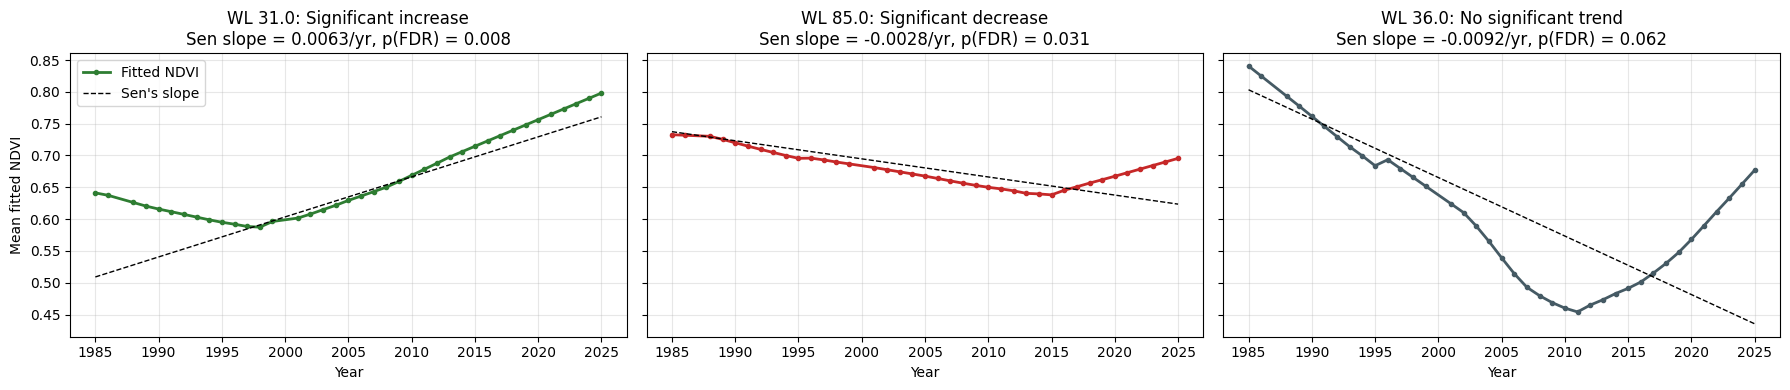

In [75]:
# %% ============================================
# STEP 9: Fitted NDVI series for example wetlands, with Sen's slope line
# ============================================
 
examples = []
for cls in ['Significant increase', 'Significant decrease', 'No significant trend']:
    ids = trends_wl.loc[trends_wl['trend_class'] == cls].sort_values('sen_slope')['wl_id']
    if len(ids):
        examples.append((cls, ids.iloc[-1] if cls == 'Significant increase' else ids.iloc[0]))
 
fig, axes = plt.subplots(1, len(examples), figsize=(6 * len(examples), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, (cls, wl) in zip(axes, examples):
    g = clean[clean['wl_id'] == wl].sort_values('year')
    t = trends_wl[trends_wl['wl_id'] == wl].iloc[0]
    line_color = colors[cls] if cls != 'No significant trend' else '#455A64'
 
    slope, intercept, _, _ = theilslopes(g['ndvi_fit'].values, g['year'].values)
    ax.plot(g['year'], g['ndvi_fit'], 'o-', color=line_color, ms=3, lw=2, label='Fitted NDVI')
    ax.plot(g['year'], intercept + slope * g['year'], '--', color='black', lw=1, label="Sen's slope")
 
    ax.set_title(f'WL {wl}: {cls}\nSen slope = {t.sen_slope:.4f}/yr, p(FDR) = {t.p_fdr:.3f}')
    ax.set_xlabel('Year')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Mean fitted NDVI')
axes[0].legend()
plt.tight_layout()
plt.savefig('wetland_trend_examples.png', dpi=150)
plt.show()

In [76]:
import geopandas as gpd

# Wetlands are smaller than watersheds, so simplify less (30 m = one Landsat pixel)
wl_simple = wl_fc.map(lambda f: f.simplify(30))
gdf_wl = geemap.ee_to_gdf(wl_simple).merge(trends_wl.drop(columns='area_km2'), on='wl_id')

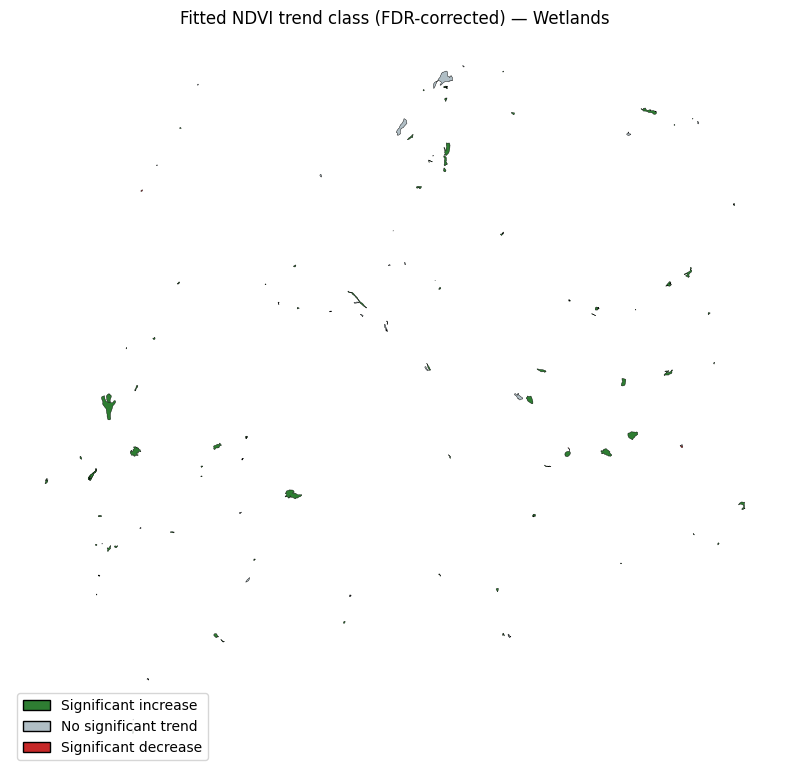

In [77]:
fig, ax = plt.subplots(figsize=(8, 8))

present = [c for c in order if c in gdf_wl['trend_class'].values]
for cls in present:
    gdf_wl[gdf_wl['trend_class'] == cls].plot(ax=ax, color=colors[cls],
                                              edgecolor='black', linewidth=0.3)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, fc=colors[c], ec='black') for c in present],
          labels=present, loc='lower left')
ax.set_title('Fitted NDVI trend class (FDR-corrected) — Wetlands')
ax.axis('off')

plt.tight_layout()
plt.savefig('wetland_trend_class_map.png', dpi=150)
plt.show()

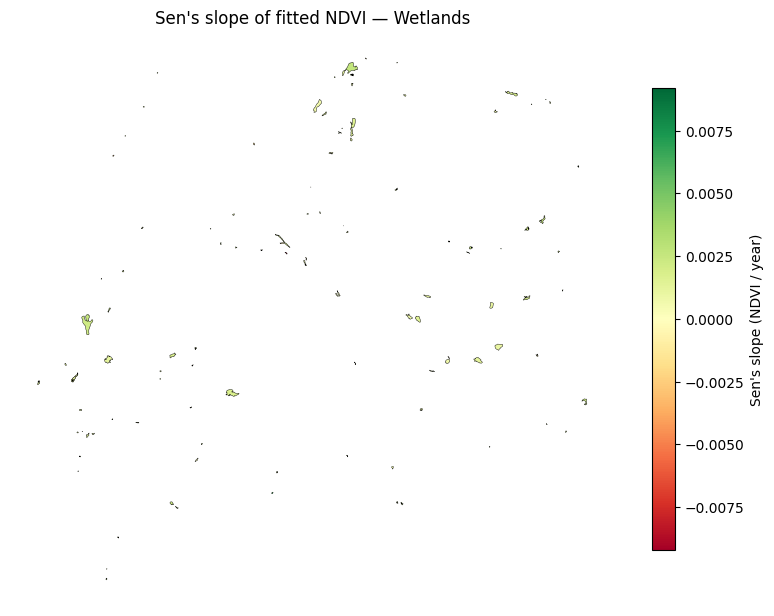

In [78]:
fig, ax = plt.subplots(figsize=(8, 8))

lim = np.nanmax(np.abs(gdf_wl['sen_slope']))
gdf_wl.plot(column='sen_slope', ax=ax, cmap='RdYlGn', vmin=-lim, vmax=lim,
            edgecolor='black', linewidth=0.3, legend=True,
            legend_kwds={'label': "Sen's slope (NDVI / year)", 'shrink': 0.6})
ax.set_title("Sen's slope of fitted NDVI — Wetlands")
ax.axis('off')

plt.tight_layout()
plt.savefig('wetland_sen_slope_map.png', dpi=150)
plt.show()